In [1]:
from fredapi import Fred
import numpy as np
import yfinance as yf
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
from scipy.signal import savgol_filter
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_absolute_error
import warnings

warnings.filterwarnings("ignore")

## Data collection and cleaning

In [2]:

FRED_API_KEY = "adf5faa6d759eb1f4b335cef60ade574"
START_DATE = "2004-11-01"
END_DATE = datetime.today().strftime("%Y-%m-%d")

fred = Fred(api_key=FRED_API_KEY)

# -----------------------------------------
# DOWNLOAD FRED MACRO DATA
# -----------------------------------------
dxy = fred.get_series("DTWEXBGS", observation_start=START_DATE)
real_yield = fred.get_series("DFII10", observation_start=START_DATE)
breakeven = fred.get_series("T10YIE", observation_start=START_DATE)
fed_funds = fred.get_series("DFF", observation_start=START_DATE)
oil = fred.get_series("DCOILWTICO", observation_start=START_DATE)

cpi = fred.get_series("CPIAUCSL", observation_start=START_DATE)
m2 = fred.get_series("M2SL", observation_start=START_DATE)

# -----------------------------------------
# TRANSFORM MONTHLY SERIES
# -----------------------------------------
cpi = cpi.resample("M").last()
m2 = m2.resample("M").last()

cpi_yoy = cpi.pct_change(12) * 100
m2_yoy = m2.pct_change(12) * 100

# Lag monthly macro to avoid look-ahead bias
cpi_yoy = cpi_yoy.shift(1)
m2_yoy = m2_yoy.shift(1)

# -----------------------------------------
# DOWNLOAD MARKET DATA (YAHOO)
# -----------------------------------------
gold = yf.download("GC=F", start=START_DATE, end=END_DATE)["Close"]
sp500 = yf.download("^GSPC", start=START_DATE, end=END_DATE)["Close"]
vix = yf.download("^VIX", start=START_DATE, end=END_DATE)["Close"]

# -----------------------------------------
# COMBINE DAILY DATA
# -----------------------------------------
daily_data = pd.concat(
    [gold, dxy, real_yield, breakeven, fed_funds, oil, sp500, vix],
    axis=1
)

daily_data.columns = [
    "Gold",
    "DXY",
    "Real_Yield_10Y",
    "Breakeven_10Y",
    "Fed_Funds",
    "WTI_Oil",
    "SP500",
    "VIX"
]


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [3]:

START_DATE = "2006-01-01"

# -----------------------------------------
# ADD MONTHLY MACRO (CPI & M2)
# -----------------------------------------
monthly_macro = pd.concat([cpi_yoy, m2_yoy], axis=1)
monthly_macro.columns = ["CPI_YoY", "M2_YoY"]

monthly_macro_daily = monthly_macro.resample("D").ffill()

last_day = gold.index[-1]
monthly_macro_daily = monthly_macro_daily.reindex(
    pd.date_range(start=monthly_macro_daily.index[0], end=last_day, freq="D")
).ffill()

# -----------------------------------------
# FINAL DATASET
# -----------------------------------------
df = pd.concat([daily_data, monthly_macro_daily], axis=1)
df = df.loc[START_DATE:]



In [4]:
df = df.dropna(subset=['Gold'])

In [5]:
df = df.ffill()

In [6]:
df.isna().sum()

Gold              0
DXY               0
Real_Yield_10Y    0
Breakeven_10Y     0
Fed_Funds         0
WTI_Oil           0
SP500             0
VIX               0
CPI_YoY           0
M2_YoY            0
dtype: int64

In [7]:
final_data = df

## Plotting raw data

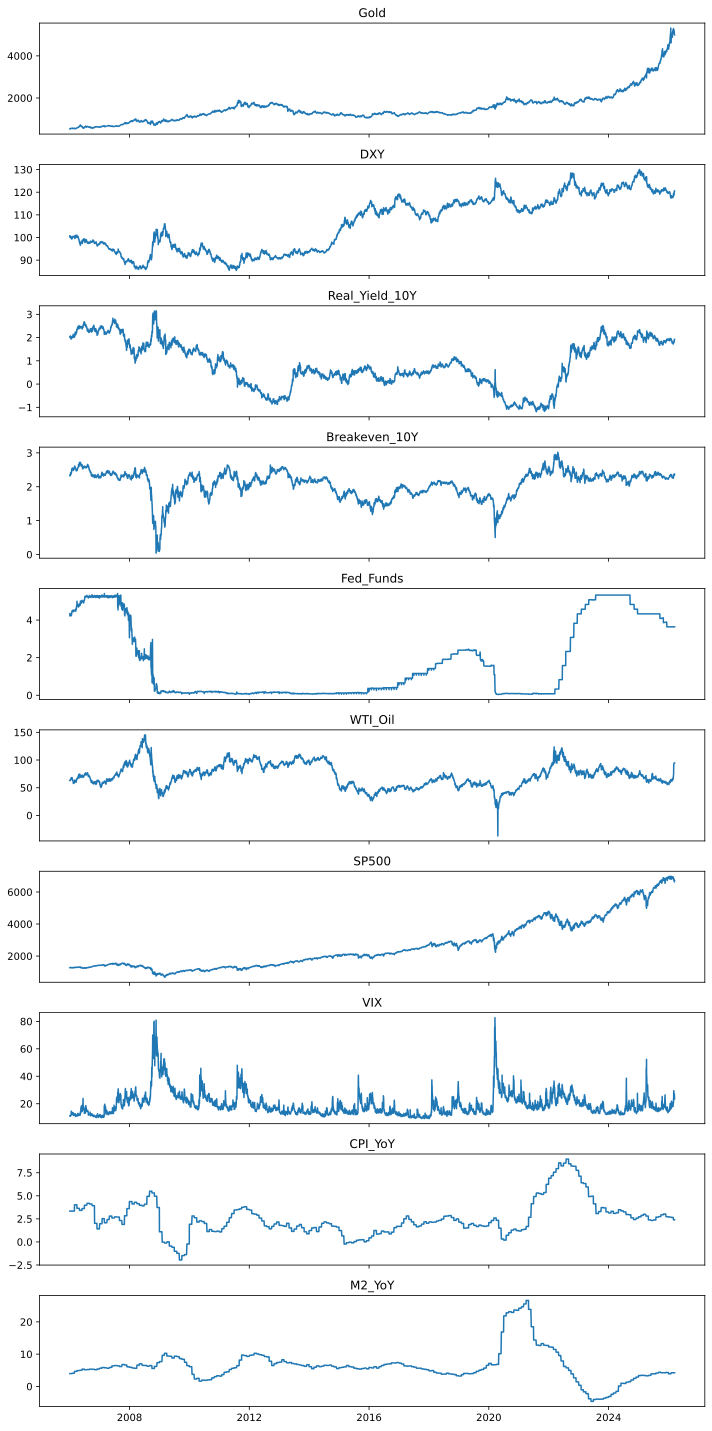

In [8]:
fig, axes = plt.subplots(10, 1, figsize=(10, 20), sharex=True)

for i, col in enumerate(final_data.columns):
    axes[i].plot(final_data.index, final_data[col])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

## Correlation heatmap between all variables

In [9]:
corr_matrix = final_data.corr()

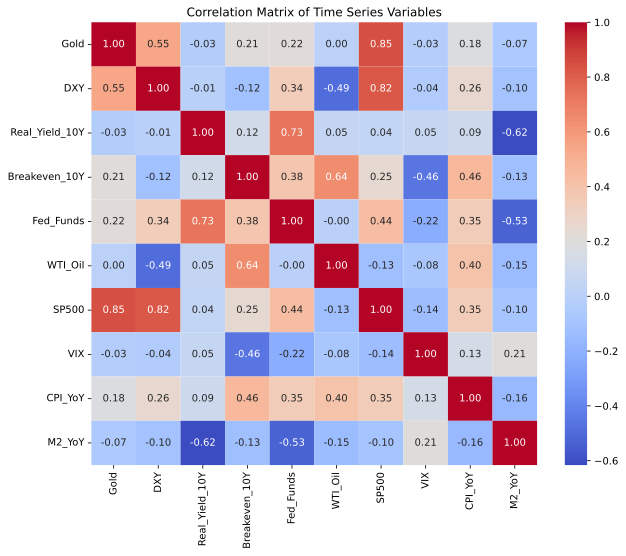

In [10]:
import seaborn as sns

plt.figure(figsize=(10, 8))  # adjust size as needed
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Time Series Variables")
plt.show()

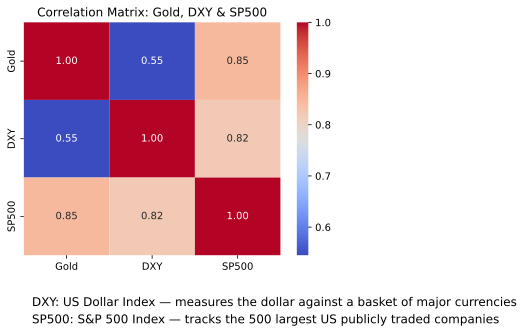

In [14]:
corr_matrix = df[["Gold", "DXY", "SP500"]].corr()

plt.figure(figsize=(5, 4))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix: Gold, DXY & SP500")

plt.figtext(0.1, -0.08, "DXY: US Dollar Index — measures the dollar against a basket of major currencies",
            fontsize=12, ha="left")
plt.figtext(0.1, -0.14, "SP500: S&P 500 Index — tracks the 500 largest US publicly traded companies",
            fontsize=12, ha="left")

plt.tight_layout()
plt.savefig("results/p1_corr.png", bbox_inches="tight")
plt.show()

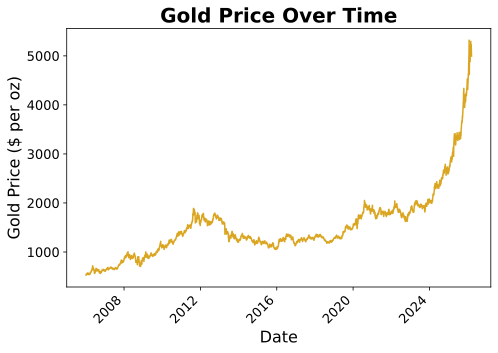

In [17]:
plt.figure(figsize=(7, 5))
plt.plot(final_data.index, final_data["Gold"], color="goldenrod", linewidth=1.5)
plt.title("Gold Price Over Time", fontsize=20, fontweight="bold")
plt.xlabel("Date", fontsize=16)
plt.ylabel("Gold Price ($ per oz)", fontsize=16)
plt.xticks(fontsize=13, rotation=45, ha="right")
plt.yticks(fontsize=13)
plt.tight_layout()
plt.savefig("results/p1_gold.png", bbox_inches="tight")
plt.show()